In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from scipy.integrate import trapezoid

# aDM BIREFRINGENCE 

In [16]:
# radius range
r = np.logspace(-1, 2, 2000) #kpc (0.1 to 10 kpc ) 
#if specifically r = np.logspace(np.log10(0.1), np.log10(8.2), 5000)

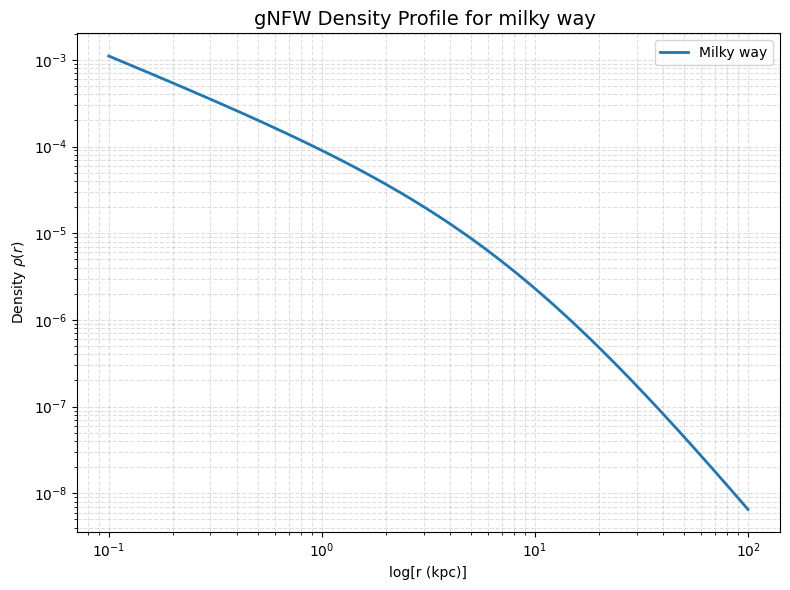

In [17]:
#NFW 

#rho_0 = 1.8 Gev/cm3
#r_s = 8.2 kpc
#b = 1  

rho0_GeVcm3 = 1.8    # 1 GeV/cm^3 -> eV^4
GeVcm3_to_eV4 = 0.00768 *1e-3 # 1cm = 5.068 * 1e13 GeV-1 

rho_0 = rho0_GeVcm3 * GeVcm3_to_eV4      # eV^4
r_s =  8.2  #kpc


#ONE SIDED 
# gNFW
def gnfw(r, rho_0, r_s):
    
    x = r / r_s
    return rho_0 / ((x) * (1 + x)**(2))



# densities
rho1 = gnfw(r, rho_0, r_s)

# plot
plt.figure(figsize=(8,6))

plt.loglog(r, rho1,linewidth=2,label='Milky way')


plt.xlabel(r'log[r (kpc)]')
plt.ylabel(r'Density $\rho(r)$')
plt.title('gNFW Density Profile for milky way ', fontsize=14)

plt.legend()

plt.grid(
    True,
    which='both',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

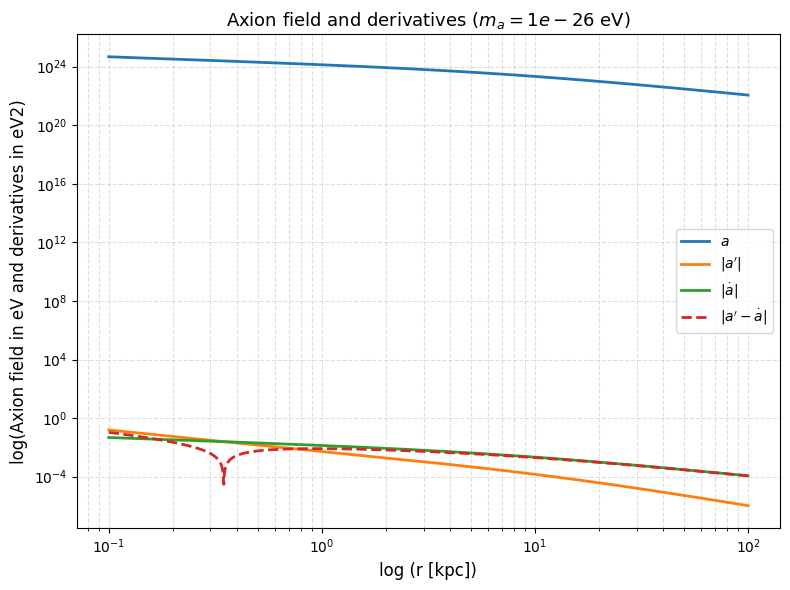

In [18]:
#AXION FIELD ( all of this is b=0 , so z=r , that we'll need to change for imapct parameters, as r2 = z2 + b2 ) 

m_a = 1e-26#ev

kpc_to_eVinv = 1.56 * 1e26  # 1 kpc = 3.086 *1e21 cm 

rs_inev = r_s * kpc_to_eVinv

def a(r):
    rho = gnfw(r, rho_0, r_s)
    return np.sqrt(2 * rho) / m_a

def a_dot(r):
    x = r / r_s
    return (-1*  np.sqrt(2 * rho_0) * (x)**-0.5 * (1 + x)**-1  )

def a_prime(r):
    x = r / r_s
    return ( ( np.sqrt(2 * rho_0) / ( m_a * rs_inev) ) * ((-0.5 * (x)**-1.5 * (1 + x)**-1) + (-1* (x)**-0.5 * (1 + x)**-2)))

plt.figure(figsize=(8, 6))

plt.loglog(r,a(r),lw=2,label=r'$a$')
plt.loglog(r,np.abs(a_prime(r)),'-',lw=2,label=r'$|a^\prime|$')
plt.loglog(r,np.abs(a_dot(r)),'-',lw=2,label=r'$|\dot a|$')
plt.loglog(r,np.abs(a_prime(r) - a_dot(r)),'--',lw=2,label=r'$|a^\prime - \dot a|$')


plt.xlabel('log (r [kpc])', fontsize=12)
plt.ylabel('log(Axion field in eV and derivatives in eV2)', fontsize=12)

plt.title(rf'Axion field and derivatives ($m_a={m_a:.0e}$ eV)',fontsize=13)

plt.grid(True, which='both',
         linestyle='--',
         alpha=0.4)

plt.legend()
plt.tight_layout()
plt.show()


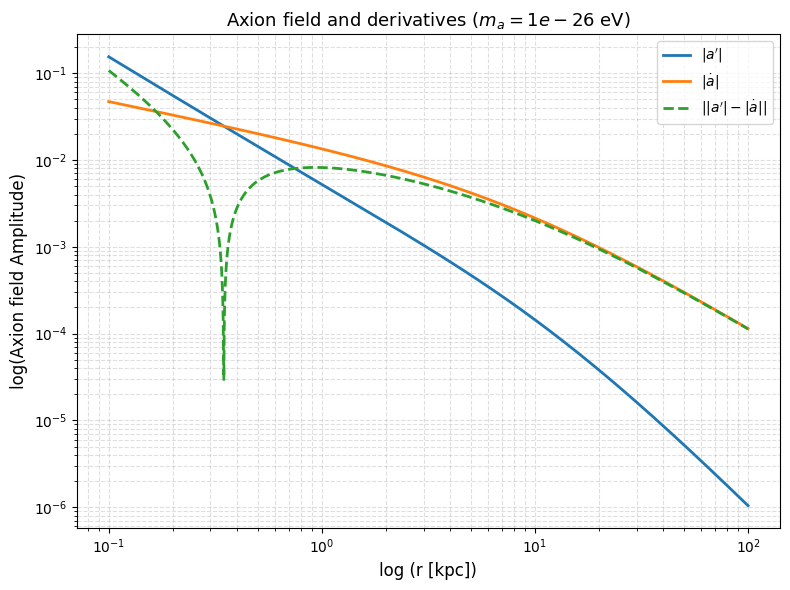

In [19]:
#PLOTTING THE DERIVATIVES ONLY

plt.figure(figsize=(8, 6))

plt.loglog(r,np.abs(a_prime(r)),'-',lw=2,label=r'$|a^\prime|$')
plt.loglog(r,np.abs(a_dot(r)),'-',lw=2,label=r'$|\dot a|$')
plt.loglog(r,np.abs(a_prime(r) - a_dot(r)),'--',lw=2,label=r'$| |a^\prime| - |\dot a||$')


plt.xlabel('log (r [kpc])', fontsize=12)
plt.ylabel('log(Axion field Amplitude)', fontsize=12)

plt.title(rf'Axion field and derivatives ($m_a={m_a:.0e}$ eV)',fontsize=13)

plt.grid(True, which='both',
         linestyle='--',
         alpha=0.4)

plt.legend()
plt.tight_layout()
plt.show()


# ELECTRON DENSITY 

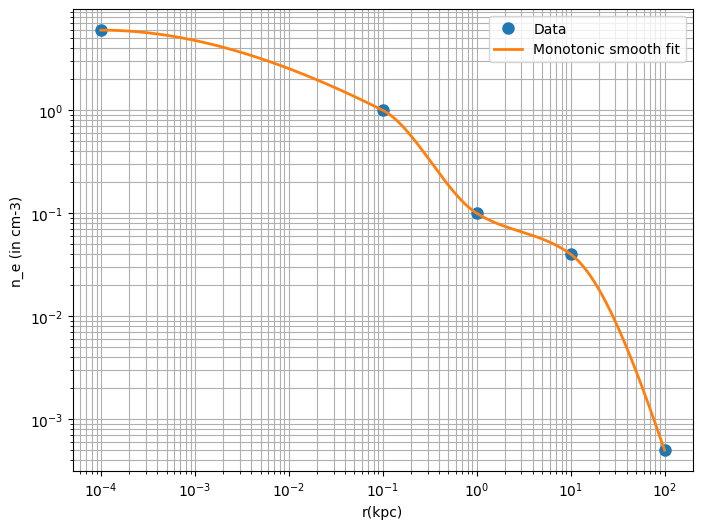

In [20]:
#Electron density in galaxy (milky way), from Yao, Manchester, Wang , https://arxiv.org/pdf/1610.09448
from scipy.interpolate import PchipInterpolator
from scipy.integrate import trapezoid

x = np.array([1e-4, 1e-1, 1, 1e1, 1e2])#kpc
y = np.array([6, 1, 0.1, 4e-2, 5e-4]) #Churasov too 

# interpolate in log-log space
logx = np.log10(x)
logy = np.log10(y)

interp = PchipInterpolator(logx, logy)
#PCHIP stands for Piecewise Cubic Hermite Interpolating Polynomial.

xfit = np.logspace(logx.min(), logx.max(), 2000)
yfit = 10**interp(np.log10(xfit))
plt.figure(figsize=(8,6))
plt.loglog(x, y, 'o', ms=8, label='Data')
plt.loglog(xfit, yfit, lw=2, label='Monotonic smooth fit')

plt.xlabel('r(kpc)')
plt.ylabel('n_e (in cm-3)')
plt.grid(True, which='both')
plt.legend()
plt.show()

In [26]:
#for a constant wp and lambda_square at 54 MHz, 

#prefactor 
g_agg_Normal =  0.66 * 1e-10 #GeV−1
g_agg = g_agg_Normal * 1e-9 #eV-1

cm_inv_to_ev = 1.97 *1e-5
# ne(z) = 6 cm -3 at core 

cm_to_eVinv = 5.067e4
lambda_natural = 555.17 * cm_to_eVinv #54MHz = 555.17 cm 
    
def integrand(z):
    return  ne(z) * (cm_inv_to_ev**3) * ( np.abs(a_prime(z) - a_dot(z)) )
    
from scipy.integrate import simpson
area = simpson(integrand(r), x = r*kpc_to_eVinv)
e_sq = 0.0854**2 #in natual units
me = 5.11 *1e5 #eV
#4 pi epsilon = 1 in natural units 

prefactor = (g_agg /4)* (lambda_natural**3) * (2*np.pi * np.pi) * ( e_sq /me)

#time delay 
DeltaT=  prefactor * area 

#time in seconds 
eVinv_to_s = 6.58e-16
T_sec = DeltaT * eVinv_to_s


#axion birefringence delta a = c * time delay / (2 *lambda)
c = 1

DeltaA = (c/(2*lambda_natural)) * DeltaT
wrapped_DeltaA = np.degrees(DeltaA) % 180 

A_SI = T_sec * (3e8) / (2 * 5.55 )
A_deg =( np.degrees(A_SI) ) % 180

print(DeltaT)
print(T_sec)
print(DeltaA)
print (wrapped_DeltaA)   #Anlge in natural units means angle in radians...
print(A_deg)

1016728.6512501052
6.690074525225693e-10
0.018071665203681645
1.0354301449443855
1.0359811754687032


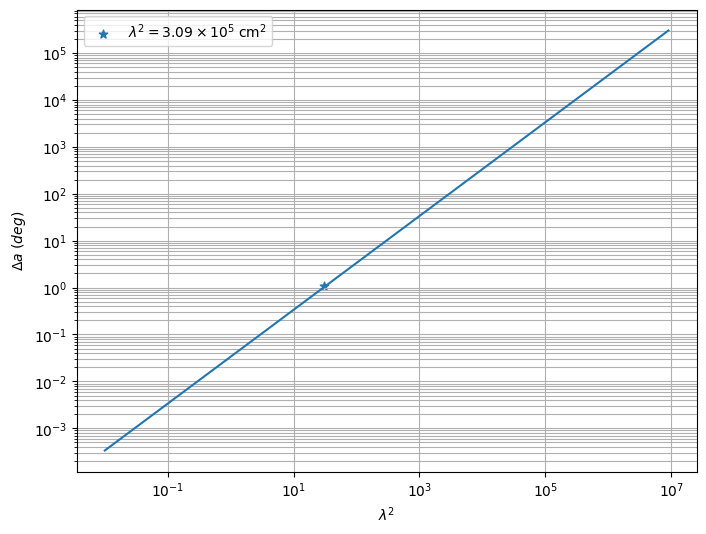

1.0804187501289215


In [41]:
#aDM birefringence from time delay 


#axion birefringence delta a = c * time delay / (2 *lambda)
c = 1
lambda_cm = np.linspace(10,3e5,1000)

cm_to_eVinv = 5.067e4
lambda_natural = lambda_cm * cm_to_eVinv #54MHz = 555.17 cm 

def ne(r):
    return 10**interp(np.log10(r))
    
def integrand(z):
    return ne(z) * (cm_inv_to_ev**3) * ( np.abs(a_prime(z) - a_dot(z)) )
    
    
from scipy.integrate import simpson
area = simpson(integrand(r), x = r*kpc_to_eVinv)

e_sq = 0.0854**2 #in natual units
me = 5.11 *1e5 #eV
#4 pi epsilon = 1 in natural units 

prefactor = (g_agg /4)* (lambda_natural**3) * (2*np.pi * np.pi) * ( e_sq /me)

#time delay 
DeltaT=  prefactor * area 

#time in seconds 
eVinv_to_s = 6.58e-16
T_sec = DeltaT * eVinv_to_s


#axion birefringence delta a = c * time delay / (2 *lambda)
c =1 # 3e8

#DeltaA = (c/2) * (T_sec) / (lambda_cm *1e-2)
DeltaA = (c/(2*lambda_natural)) * DeltaT
DeltaA_deg = np.degrees(DeltaA)

# ---- FIX 2: correct interpolation axis ----
lambda_sq0 = 3.08e5  # cm^2
lambda0 = np.sqrt(lambda_sq0)

DeltaA0 = np.interp(lambda0, lambda_cm, DeltaA_deg)

plt.figure(figsize=(8,6))

# ---- FIX 3: consistent x-axis ----
plt.loglog((lambda_cm*1e-2)**2, np.abs(DeltaA_deg))

plt.scatter(lambda_sq0*1e-4, DeltaA0,
            s=40, marker='*',
            label=r'$\lambda^2=3.09\times10^5\ \mathrm{cm}^2$')

plt.xlabel(r'$\lambda^2$')
plt.ylabel(r'$\Delta a\ (deg)$')
plt.grid(True, which='both')
plt.legend()
plt.show()

wrapped_DeltaA0 = DeltaA0 % 180
print(wrapped_DeltaA0)

# FARADAY ROTATION 

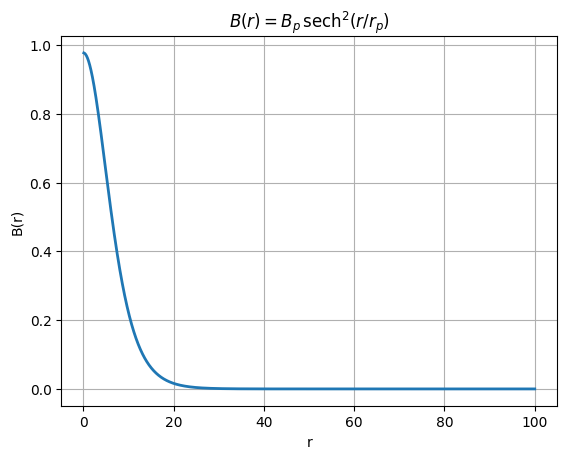

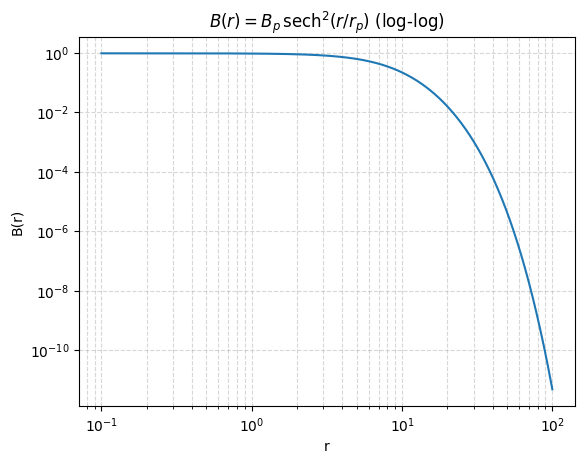

In [24]:
#Magnetic field 

#For the B_parallel, from https://arxiv.org/pdf/2311.12120
#sech2 plot 

Bp = 0.978 #+-0.033 #muG   # peak magnetic field
rp = 7.29  #+- 0.06 #kpc  # scale radius
# --------------------


B = Bp * (1 / np.cosh(r / rp))**2   # sech^2(x) = 1/cosh^2(x)

plt.plot(r, B, lw=2)
plt.xlabel("r")
plt.ylabel("B(r)")
plt.title(r"$B(r) = B_p \, \mathrm{sech}^2(r/r_p)$")
plt.grid(True)
plt.show()



#loglog
plt.loglog(r, B)

plt.xlabel("r")
plt.ylabel("B(r)")
plt.title(r"$B(r) = B_p \, \mathrm{sech}^2(r/r_p)$ (log-log)")
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.show()

Impact parameter b = 0.0 kpc
RM = 273.9069 rad/m^2


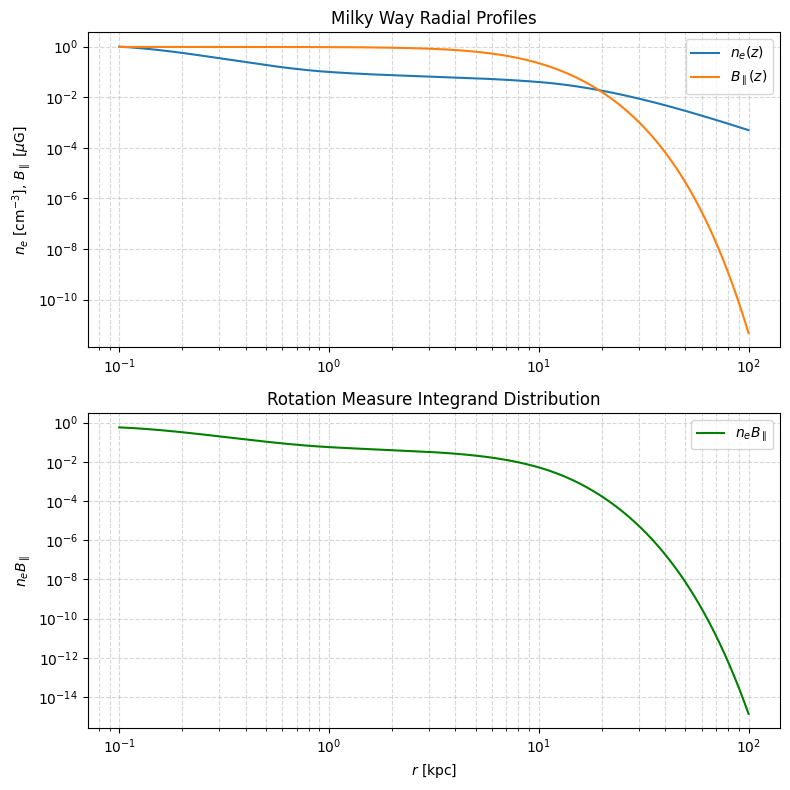

In [25]:
#Rotation measure 

b = 0.0   # kpc


# LOS component
def B_parallel(r):
    return (Bp / np.cosh(r / rp)**2) / np.sqrt(3)

def ne(r):
    return 10**interp(np.log10(r))   #PCHIP interpolation 
    
#LOS , one- sided, hanve r is from 0./1 to 8.2 kpc 
#r = np.sqrt(b**2 + z**2), and sicne b is 0 , r=z 


integrand = ne(r) * B_parallel(r)
RM = 812 * trapezoid(integrand, r)
# RM=812∫( in cm−3)(in μG )(in kpc ) -- radm−2.


print(f"Impact parameter b = {b} kpc")
print(f"RM = {RM:.4f} rad/m^2")

#Plot 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,8))

ax1.loglog(r, ne(r), label=r'$n_e(z)$')  # X AXIS WILL BE REPLACED BY Z  FOR DIFFERENT B
ax1.loglog(r, B, label=r'$B_\parallel(z)$')   # X AXIS WILL BE REPLACED BY Z  FOR DIFFERENT B
ax1.set_ylabel(r'$n_e$ [cm$^{-3}$], $B_\parallel$ [$\mu$G]')
ax1.grid(True, which='both', ls='--', alpha=0.5)
ax1.set_title(r'Milky Way Radial Profiles', fontsize=12)

ax1.legend()
ax2.loglog(r, integrand, color='green', label=r'$n_e B_\parallel$')

ax2.set_xlabel(r'$r$ [kpc]')
ax2.set_ylabel(r'$n_e B_\parallel$')
ax2.grid(True, which='both', ls='--', alpha=0.5)
ax2.set_title(r'Rotation Measure Integrand Distribution', fontsize=12)

ax2.legend()
plt.tight_layout()
plt.show()

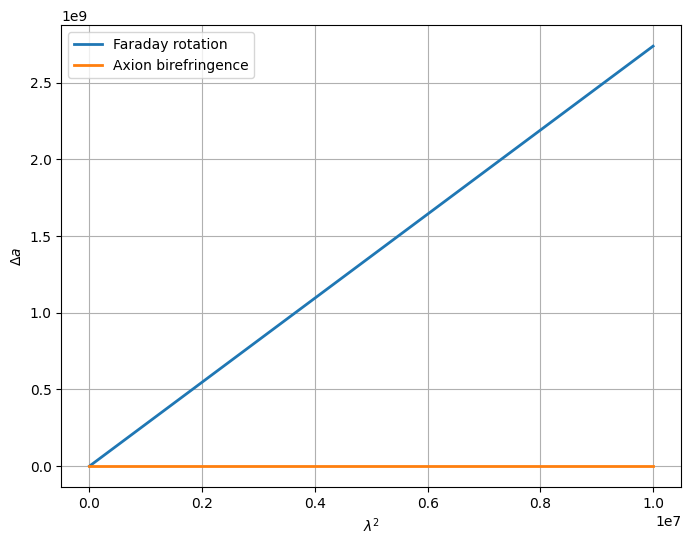

Faraday slope: 273.906855185953
Axion slope: 2.283728037891551e-17


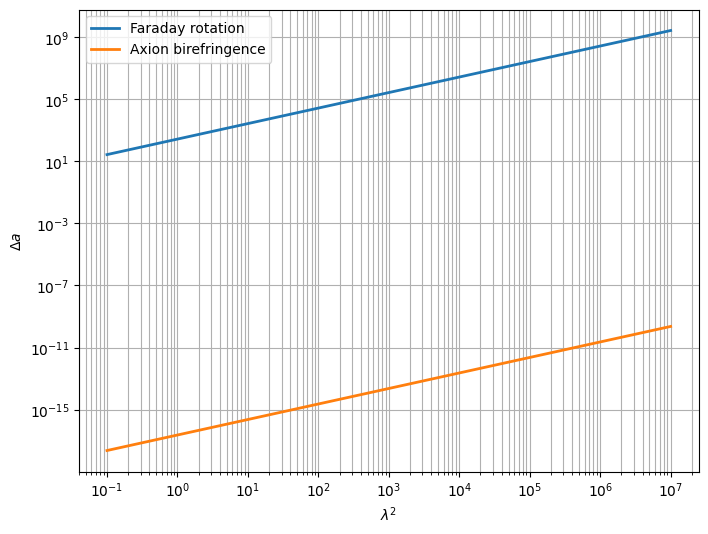

Faraday slope: 1.0000000000000002
Axion slope: 1.0000000000000004


In [42]:
# Faraday rotation angle with varying freq
lambda_sq = np.logspace(-1, 7, 1000) # 100 khz = 3000 m hence lamda_sq = 9e6
FR_changing = lambda_sq * RM   #Psi_0 term value unknown, taking it as 0

#aDM biref with varying frequency 

DeltaA_changing = (g_agg /4) * (2*np.pi*np.pi) * (e_sq / me) * (c/2) * area * lambda_sq


plt.figure(figsize=(8,6))
plt.plot(lambda_sq, FR_changing, lw=2, label='Faraday rotation')
plt.plot(lambda_sq, DeltaA_changing, lw=2, label='Axion birefringence')
plt.xlabel(r'$\lambda^2$')
plt.ylabel(r'$\Delta a$')
plt.grid(True, which='both')
plt.legend()
plt.show()

def linear_slope(x, y):
    return np.polyfit(x, y, 1)[0]
print("Faraday slope:",  linear_slope(lambda_sq, FR_changing))
print("Axion slope:", linear_slope(lambda_sq, DeltaA_changing))

plt.figure(figsize=(8,6))
plt.loglog(lambda_sq, FR_changing, lw=2, label='Faraday rotation')
plt.loglog(lambda_sq, DeltaA_changing, lw=2, label='Axion birefringence')
plt.xlabel(r'$\lambda^2$')
plt.ylabel(r'$\Delta a$')
plt.grid(True, which='both')
plt.legend()
plt.show()

# log-log slope fit
def slope(x, y):
    return np.polyfit(np.log10(x), np.log10(y), 1)[0]
    

print("Faraday slope:",  slope(lambda_sq, FR_changing))
print("Axion slope:", slope(lambda_sq, DeltaA_changing))

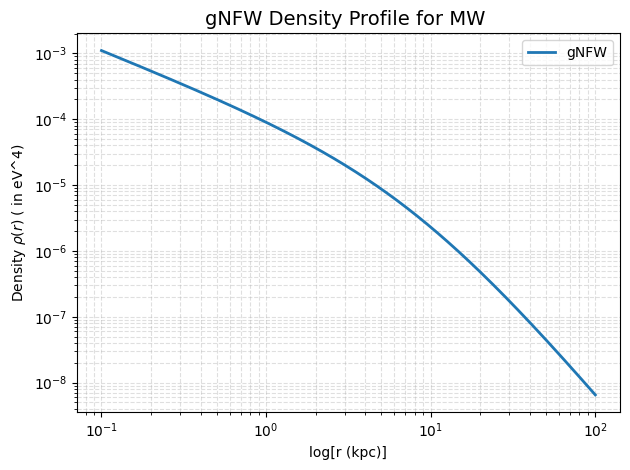

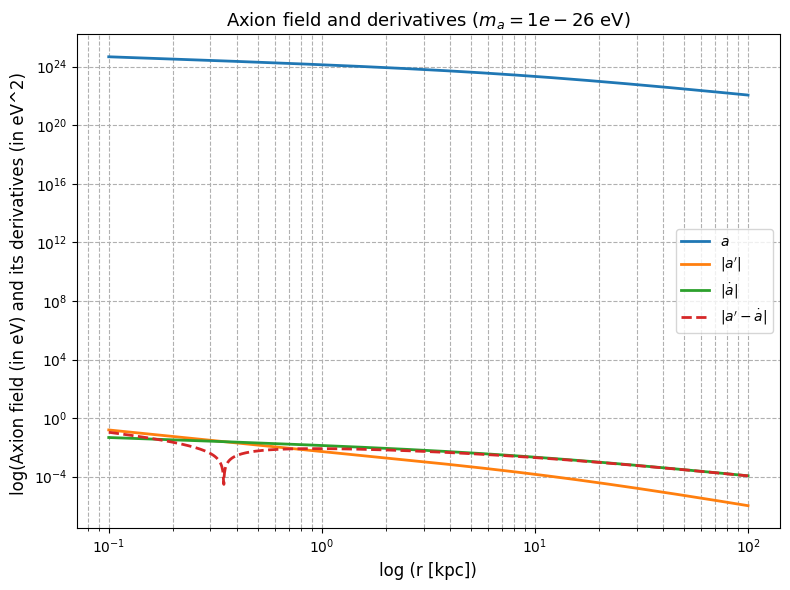

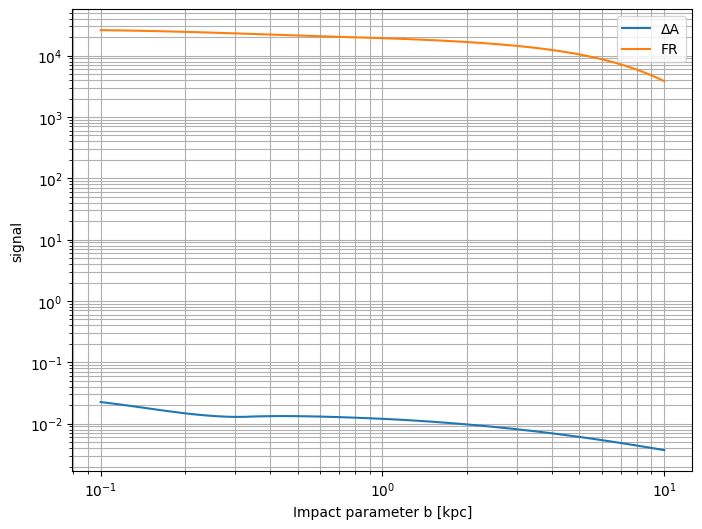

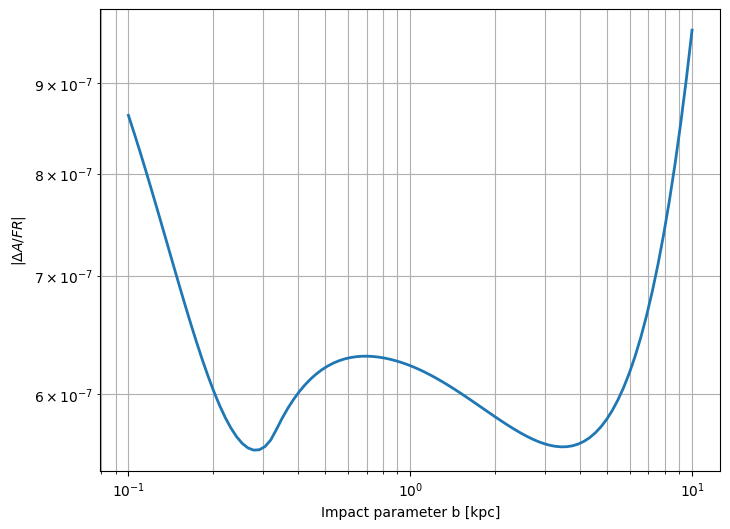

In [13]:
#CHANGING IMPACT PARAMETER 


z = np.logspace(-1, 1, 2000)  # kpc


rho0_GeVcm3 = 1.8    # 1 GeV/cm^3 -> eV^4
GeVcm3_to_eV4 = 0.00768 *1e-3 # 1cm = 5.068 * 1e13 GeV-1 

rho_0 = rho0_GeVcm3 * GeVcm3_to_eV4      # eV^4
r_s =  8.2  #kpc

m_a = 1e-26       # eV

kpc_to_eV_inv = 1.56e26
rs_natural = r_s * kpc_to_eV_inv

g_agg = 6.6e-11 * 1e-9  # eV^-1

cm_inv_to_ev = 7.68e-15
e_sq = 0.0854**2
me = 5.11e5

lambda_cm = 555.5 
lambda_natural = lambda_cm * 5.067e4

def r_los(z, b):
    return np.sqrt(z**2 + b**2)

#nfw
def gnfw(r, rho_0, r_s):
    x = r / r_s
    return rho_0 / (x * (1 + x)**2)


plt.loglog(r, gnfw(r, rho_0, r_s),linewidth=2,label='gNFW') #ev4 vs kpc 

plt.xlabel(r'log[r (kpc)]')
plt.ylabel(r'Density $\rho(r)$ ( in eV^4)')
plt.title('gNFW Density Profile for MW ', fontsize=14)

plt.legend()
plt.grid(True,which='both',linestyle='--',alpha=0.4)
plt.tight_layout()
plt.show()


#axion field and derivatives 
def a(r):
    rho = gnfw(r, rho_0, r_s)
    return np.sqrt(2 * rho) / m_a

def a_dot(r):
    x = r / r_s
    return -np.sqrt(2 * rho_0) * x**(-0.5) * (1 + x)**(-1)

def a_prime(r):
    x = r / r_s
    return (np.sqrt(2 * rho_0) / (m_a * rs_natural)) * (
        -0.5 * x**(-1.5) * (1 + x)**(-1)
        -1.0 * x**(-0.5) * (1 + x)**(-2)
    )

plt.figure(figsize=(8, 6))

plt.loglog(r,a(r),lw=2,label=r'$a$')
plt.loglog(r,np.abs(a_prime(r)),'-',lw=2,label=r'$|a^\prime|$')
plt.loglog(r,np.abs(a_dot(r)),'-',lw=2,label=r'$|\dot a|$')
plt.loglog(r,np.abs(a_prime(r) - a_dot(r)),'--',lw=2,label=r'$|a^\prime - \dot a|$')


plt.xlabel('log (r [kpc])', fontsize=12)
plt.ylabel('log(Axion field (in eV) and its derivatives (in eV^2) ', fontsize=12)

plt.title(rf'Axion field and derivatives ($m_a={m_a:.0e}$ eV)',fontsize=13)

plt.grid(True, which='both',linestyle='--')

plt.legend()
plt.tight_layout()
plt.show()


#ne model
x = np.array([1e-6, 1e-3, 1e-1, 1, 1e1])
y = np.array([20, 6, 1, 0.1, 4.8e-2])

interp = PchipInterpolator(np.log10(x), np.log10(y))

def ne(r):
    return 10**interp(np.log10(r))

#integrating along the LOS for aDM birefringence/time delay and Faraday rotation/Rotation measure  


def integrand_axion(z, b):
    r = r_los(z, b)
    return ne(r) * cm_inv_to_ev * np.abs(a_prime(r) - a_dot(r))
    

def integrand_RM(z, b, Bp=0.978, rp=7.29):

    r = r_los(z, b)
    B = Bp * (1 / np.cosh(r / rp))**2  

    return ne(r) * B

# they will be functions of b 

def axion_area(b):

    vals = integrand_axion(z, b)
    return 2 * simpson(vals, x=z * kpc_to_eV_inv)

def RM_of_b(b, Bp=0.978, rp=7.29):

    vals = integrand_RM(z, b, Bp=0.978, rp=7.29)
    return 2 * 812 * simpson(vals, x=z)

#hence we get 
def DeltaT(b):

    area = axion_area(b)
    prefactor = (g_agg / 4) * lambda_natural**3 * (2*np.pi*np.pi) * (e_sq / me)
    
    return prefactor * area


def DeltaA(b):   #in radians
    return DeltaT(b) / (2 * lambda_natural)


def FR(b): #in radians 

    RM = RM_of_b(b)
    return lambda_cm**2 * 1e-4 * RM   



#print(DeltaT)
#print(T_sec)
#print(DeltaA)
#print(FR)
#convert a to degrees

#varying with impact parameter 
b_vals = np.logspace(-1, 1, 100)

DeltaA_vals = np.array([DeltaA(b) for b in b_vals])
FR_vals     = np.array([FR(b) for b in b_vals])



plt.figure(figsize=(8,6))
plt.loglog(b_vals, np.abs(DeltaA_vals), label="ΔA")
plt.loglog(b_vals, np.abs(FR_vals), label="FR")
plt.xlabel("Impact parameter b [kpc]")
plt.ylabel("signal")
plt.grid(True, which="both")
plt.legend()
plt.show()

plt.figure(figsize=(8,6))
plt.loglog(b_vals, np.abs(DeltaA_vals / FR_vals), lw=2)
plt.xlabel("Impact parameter b [kpc]")
plt.ylabel(r"$|\Delta A / FR|$")
plt.grid(True, which="both")
plt.show()

In [14]:
for b in [0.1,0.3,1,3,7,10]:
    print(
        b,
        DeltaA(b),
        FR(b),
        DeltaA(b)/FR(b)
    )

0.1 0.022498969437198122 26066.17323075101 8.631481590345392e-07
0.3 0.012892597955701225 23065.95246829681 5.58944963292609e-07
1 0.011985005977394573 19253.687097608723 6.224784851148376e-07
3 0.00809743503853853 14406.986585590488 5.620491829038964e-07
7 0.004840830948447456 7215.283827764627 6.709134476207013e-07
10 0.0037021355619733234 3837.459692847098 9.647360124391627e-07


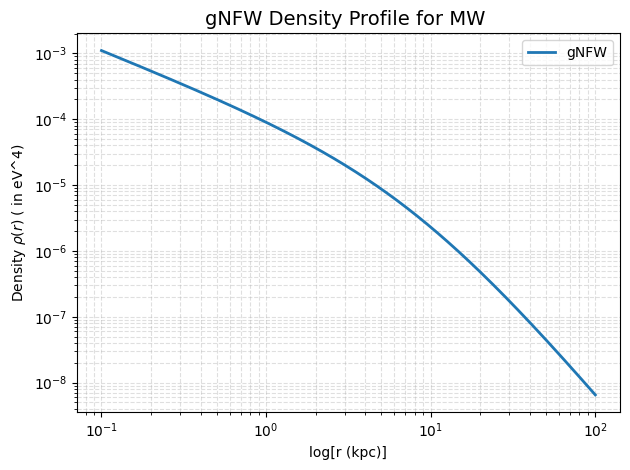

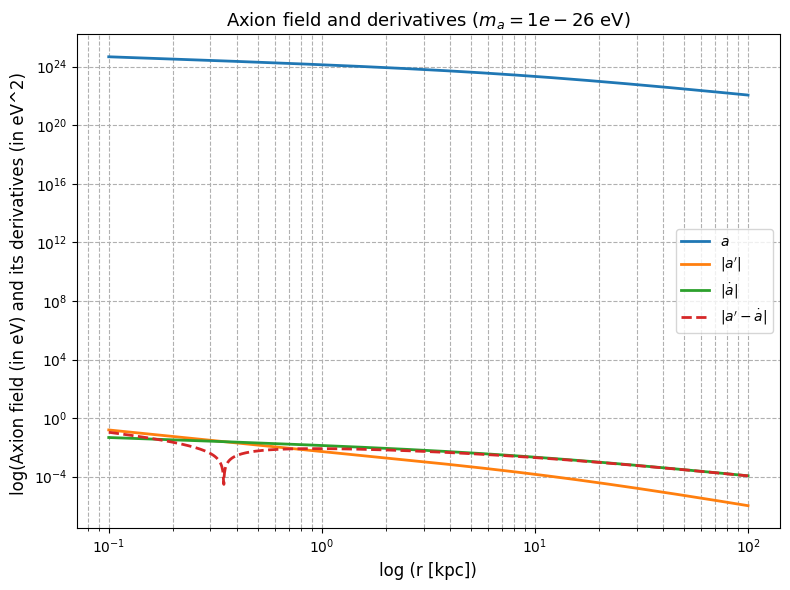

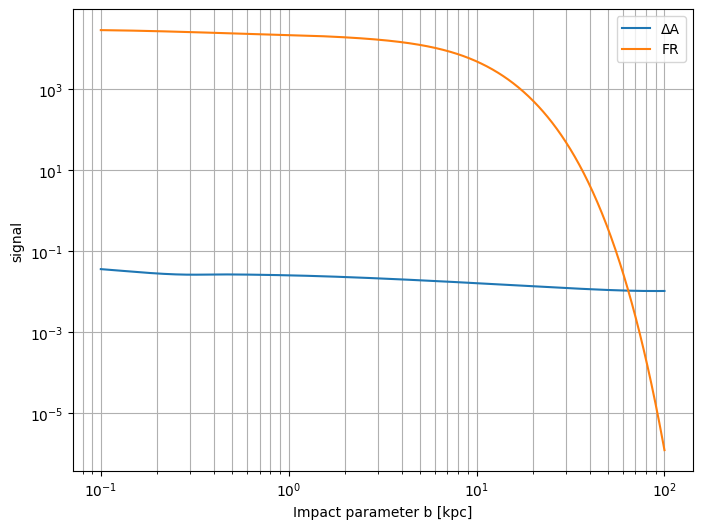

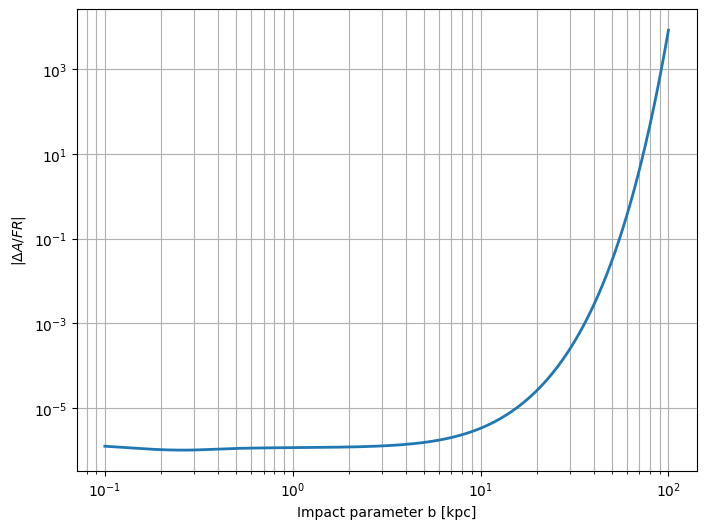

In [43]:
#for MW, TILL 100 kpc now 
#and plotting wrt b

z = np.logspace(-1, 2, 2000)  # kpc


rho0_GeVcm3 = 1.8    # 1 GeV/cm^3 -> eV^4
GeVcm3_to_eV4 = 0.00768 *1e-3 # 1cm = 5.068 * 1e13 GeV-1 

rho_0 = rho0_GeVcm3 * GeVcm3_to_eV4      # eV^4
r_s =  8.2  #kpc

m_a = 1e-26       # eV

kpc_to_eV_inv = 1.56e26
rs_natural = r_s * kpc_to_eV_inv

g_agg = 6.6e-11 * 1e-9  # eV^-1

cm_inv_to_ev = 7.68e-15
e_sq = 0.0854**2
me = 5.11e5

lambda_cm = 555.5 
lambda_natural = lambda_cm * 5.067e4

def r_los(z, b):
    return np.sqrt(z**2 + b**2)

#nfw
def gnfw(r, rho_0, r_s):
    x = r / r_s
    return rho_0 / (x * (1 + x)**2)


plt.loglog(r, gnfw(r, rho_0, r_s),linewidth=2,label='gNFW') #ev4 vs kpc 

plt.xlabel(r'log[r (kpc)]')
plt.ylabel(r'Density $\rho(r)$ ( in eV^4)')
plt.title('gNFW Density Profile for MW ', fontsize=14)

plt.legend()
plt.grid(True,which='both',linestyle='--',alpha=0.4)
plt.tight_layout()
plt.show()


#axion field and derivatives 
def a(r):
    rho = gnfw(r, rho_0, r_s)
    return np.sqrt(2 * rho) / m_a

def a_dot(r):
    x = r / r_s
    return -np.sqrt(2 * rho_0) * x**(-0.5) * (1 + x)**(-1)

def a_prime(r):
    x = r / r_s
    return (np.sqrt(2 * rho_0) / (m_a * rs_natural)) * (
        -0.5 * x**(-1.5) * (1 + x)**(-1)
        -1.0 * x**(-0.5) * (1 + x)**(-2)
    )

plt.figure(figsize=(8, 6))

plt.loglog(r,a(r),lw=2,label=r'$a$')
plt.loglog(r,np.abs(a_prime(r)),'-',lw=2,label=r'$|a^\prime|$')
plt.loglog(r,np.abs(a_dot(r)),'-',lw=2,label=r'$|\dot a|$')
plt.loglog(r,np.abs(a_prime(r) - a_dot(r)),'--',lw=2,label=r'$|a^\prime - \dot a|$')


plt.xlabel('log (r [kpc])', fontsize=12)
plt.ylabel('log(Axion field (in eV) and its derivatives (in eV^2) ', fontsize=12)

plt.title(rf'Axion field and derivatives ($m_a={m_a:.0e}$ eV)',fontsize=13)

plt.grid(True, which='both',linestyle='--')

plt.legend()
plt.tight_layout()
plt.show()


#ne model
x = np.array([1e-6, 1e-3, 1e-1, 1, 1e1])
y = np.array([20, 6, 1, 0.1, 4.8e-2])

interp = PchipInterpolator(np.log10(x), np.log10(y))

def ne(r):
    return 10**interp(np.log10(r))

#integrating along the LOS for aDM birefringence/time delay and Faraday rotation/Rotation measure  


def integrand_axion(z, b):
    r = r_los(z, b)
    return ne(r) * cm_inv_to_ev * np.abs(a_prime(r) - a_dot(r))
    

def integrand_RM(z, b, Bp=0.978, rp=7.29):

    r = r_los(z, b)
    B = Bp * (1 / np.cosh(r / rp))**2  

    return ne(r) * B

# they will be functions of b 

def axion_area(b):

    vals = integrand_axion(z, b)
    return 2 * simpson(vals, x=z * kpc_to_eV_inv)

def RM_of_b(b, Bp=0.978, rp=7.29):

    vals = integrand_RM(z, b, Bp=0.978, rp=7.29)
    return 2 * 812 * simpson(vals, x=z)

#hence we get 
def DeltaT(b):

    area = axion_area(b)
    prefactor = (g_agg / 4) * lambda_natural**3 * (2*np.pi*np.pi) * (e_sq / me)
    
    return prefactor * area


def DeltaA(b):   #in radians
    return DeltaT(b) / (2 * lambda_natural)


def FR(b): #in radians 

    RM = RM_of_b(b)
    return lambda_cm**2 * 1e-4 * RM   



#print(DeltaT)
#print(T_sec)
#print(DeltaA)
#print(FR)
#convert a to degrees

#varying with impact parameter 
b_vals = np.logspace(-1, 2, 1000)

DeltaA_vals = np.array([DeltaA(b) for b in b_vals])
FR_vals     = np.array([FR(b) for b in b_vals])



plt.figure(figsize=(8,6))
plt.loglog(b_vals, np.abs(DeltaA_vals), label="ΔA")
plt.loglog(b_vals, np.abs(FR_vals), label="FR")
plt.xlabel("Impact parameter b [kpc]")
plt.ylabel("signal")
plt.grid(True, which="both")
plt.legend()
plt.show()

plt.figure(figsize=(8,6))
plt.loglog(b_vals, np.abs(DeltaA_vals / FR_vals), lw=2)
plt.xlabel("Impact parameter b [kpc]")
plt.ylabel(r"$|\Delta A / FR|$")
plt.grid(True, which="both")
plt.show()